In [101]:
import warnings
warnings.filterwarnings('ignore')

In [122]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("HR_Employee_Attrition.csv")

In [123]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [124]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [126]:
from sklearn.preprocessing import LabelEncoder

# Encoding binary categorical columns
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])  # Yes/No → 1/0
df['OverTime'] = le.fit_transform(df['OverTime'])  # Yes/No → 1/0
df['Gender'] = le.fit_transform(df['Gender'])  # Male/Female → 1/0
df['Over18'] = le.fit_transform(df['Over18'])

In [127]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first=True)

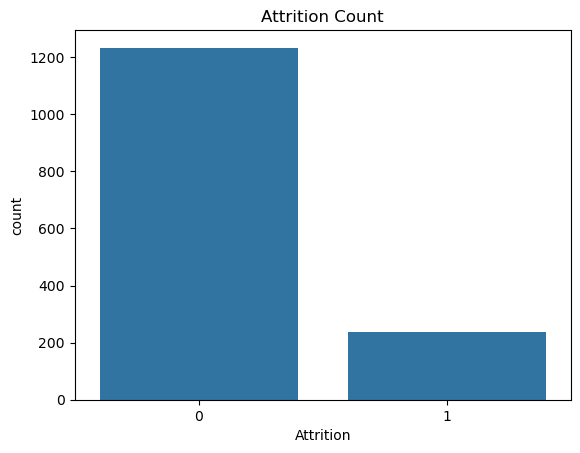

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot attrition count
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Count")
plt.show()


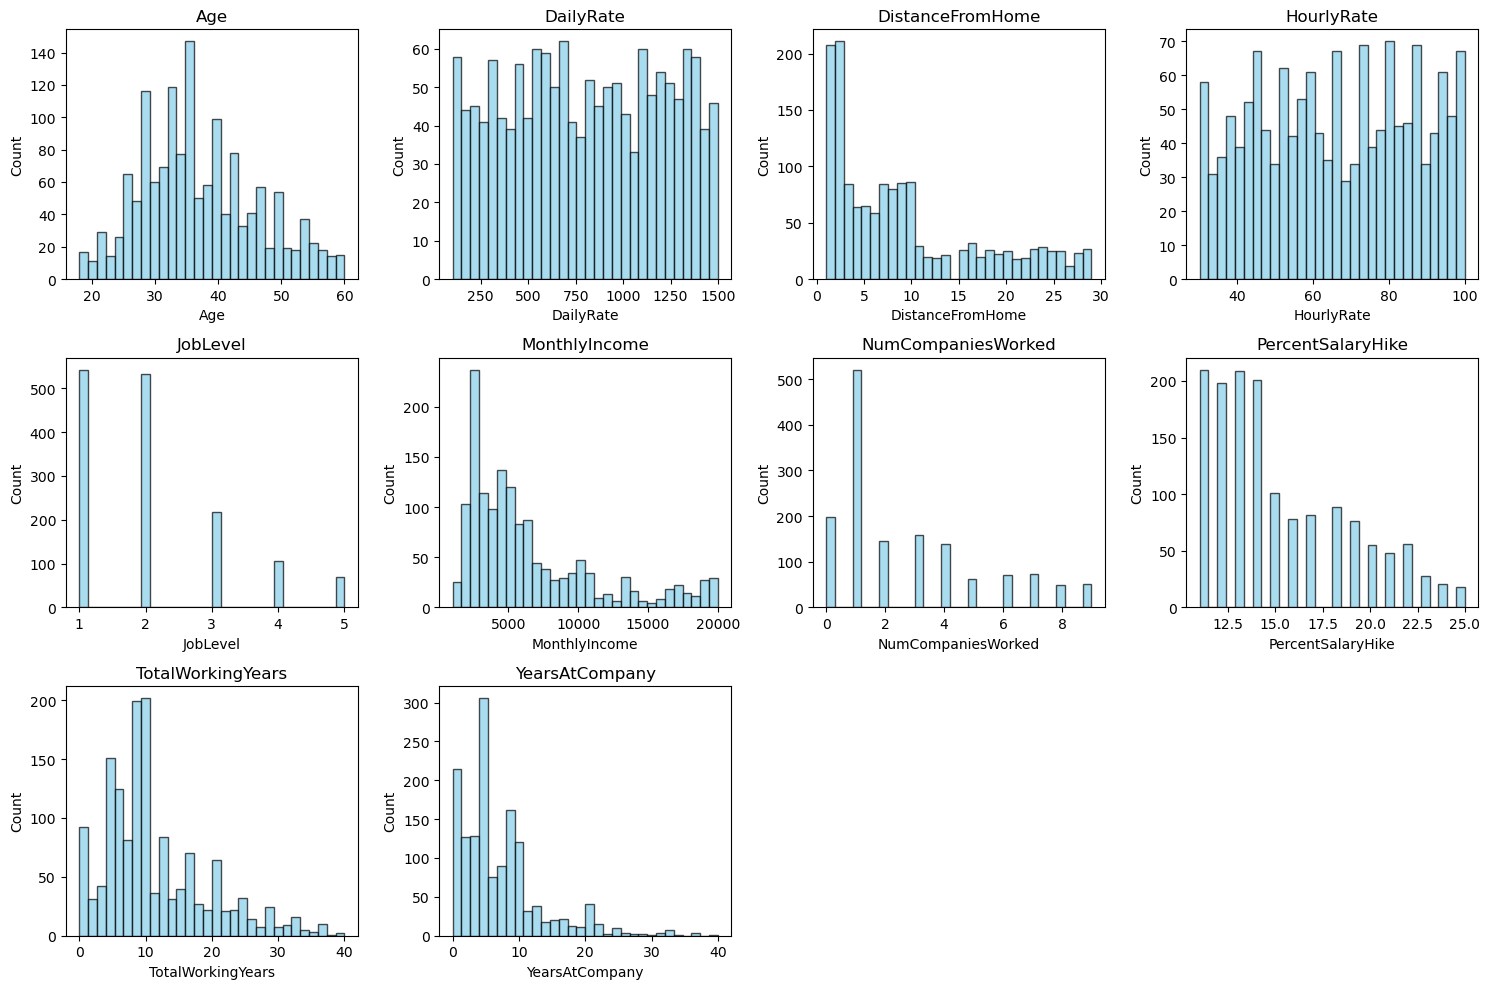

In [129]:
import matplotlib.pyplot as plt

# List of key numerical features to visualize
key_features = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 
                'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 
                'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany']

# Set figure size
plt.figure(figsize=(15, 10))

# Loop through each feature and plot a histogram
for i, feature in enumerate(key_features, 1):
    plt.subplot(3, 4, i)  # Create subplots (3 rows, 4 columns)
    plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [130]:
import pandas as pd

# Calculate summary statistics
stats_df = df[key_features].describe().T  # Transpose for better readability
stats_df['variance'] = df[key_features].var()  # Add variance

# Display the results
print(stats_df[['mean', '50%', 'std', 'variance']].rename(columns={'50%': 'median'}))


                           mean  median          std      variance
Age                   36.923810    36.0     9.135373  8.345505e+01
DailyRate            802.485714   802.0   403.509100  1.628196e+05
DistanceFromHome       9.192517     7.0     8.106864  6.572125e+01
HourlyRate            65.891156    66.0    20.329428  4.132856e+02
JobLevel               2.063946     2.0     1.106940  1.225316e+00
MonthlyIncome       6502.931293  4919.0  4707.956783  2.216486e+07
NumCompaniesWorked     2.693197     2.0     2.498009  6.240049e+00
PercentSalaryHike     15.209524    14.0     3.659938  1.339514e+01
TotalWorkingYears     11.279592    10.0     7.780782  6.054056e+01
YearsAtCompany         7.008163     5.0     6.126525  3.753431e+01


In [131]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assuming df is your dataframe and 'Attrition' is the target column
# Split data into features (X) and target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Check if any column in X contains non-numeric values
# For simplicity, convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical features

# Convert the target variable to numeric using LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print(pd.Series(y_resampled).value_counts())

# If you want to convert the labels back to original ('Y', 'N')
y_resampled = le.inverse_transform(y_resampled)

df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Attrition'] = y_resampled


1    1233
0    1233
Name: count, dtype: int64


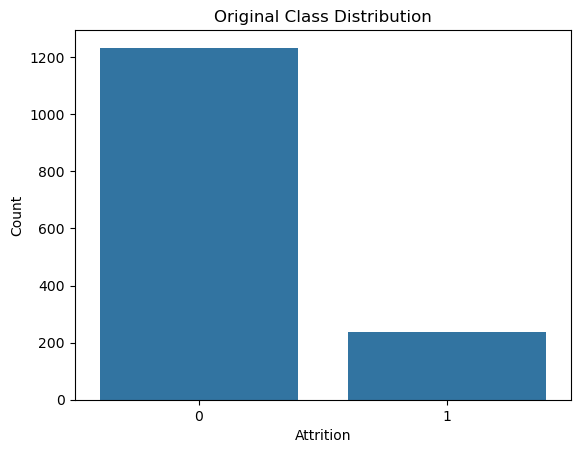

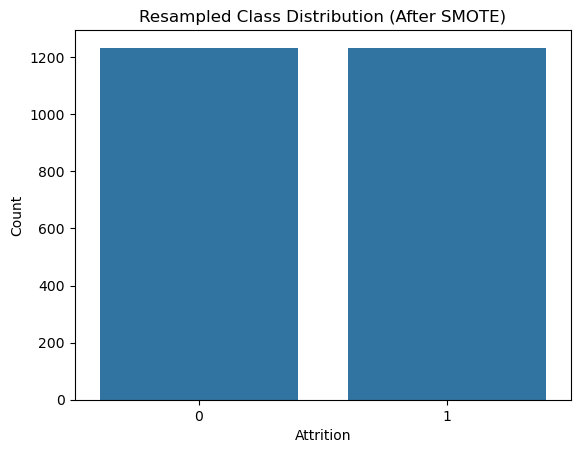

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the count plot for the original target variable 'Attrition'
sns.countplot(x=y)  # For the original 'y' (before SMOTE)
plt.title('Original Class Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

# Plot the count plot for the resampled target variable 'y_resampled' (after SMOTE)
sns.countplot(x=y_resampled)  # For the resampled 'y_resampled' (after SMOTE)
plt.title('Resampled Class Distribution (After SMOTE)')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()


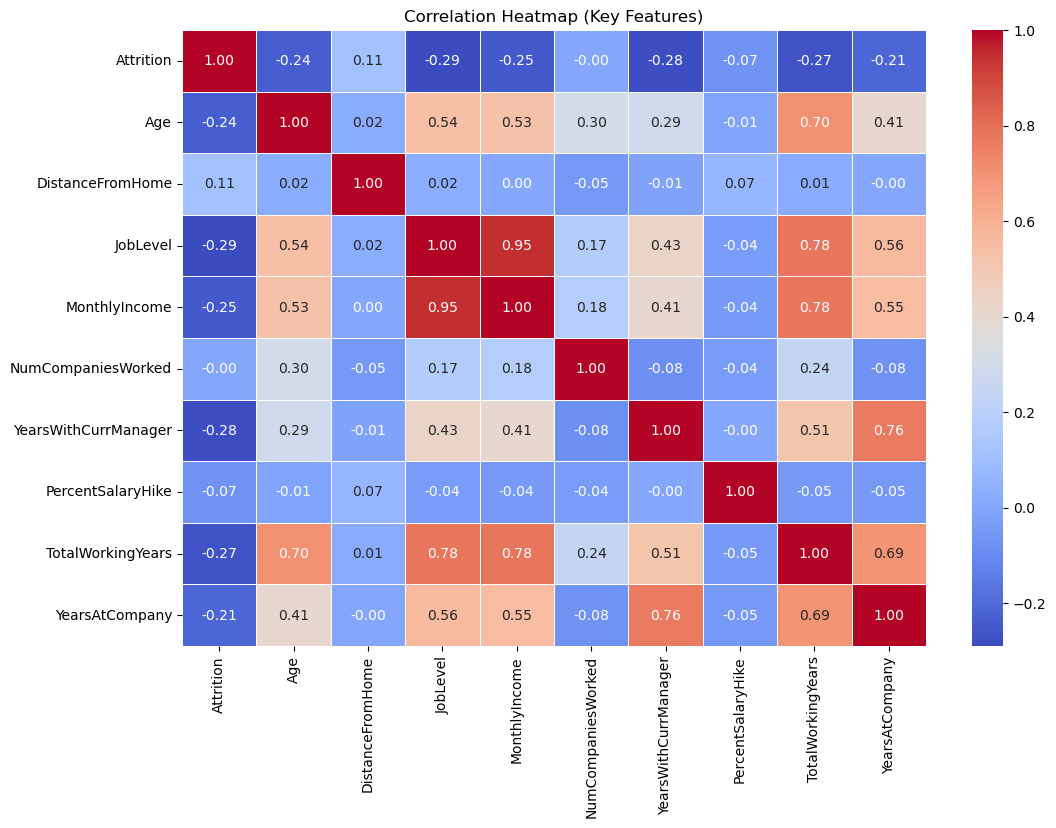

In [133]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical columns using Label Encoding
categorical_columns = df_resampled.select_dtypes(include=['object']).columns
key_features = ['Attrition','Age', 'DistanceFromHome', 
                'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked','YearsWithCurrManager', 
                'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany']

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_resampled[col] = le.fit_transform(df_resampled[col])
    label_encoders[col] = le

# Subset DataFrame to only include key features
df_key_features = df_resampled[key_features]

# Compute correlation matrix for key features only
corr_matrix = df_key_features.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Key Features)")
plt.show()


In [134]:
# Mutual Information score
from sklearn.feature_selection import mutual_info_classif

categorical_cols = df_resampled.select_dtypes(include=['object']).columns
df_resampled[categorical_cols] = df_resampled[categorical_cols].apply(LabelEncoder().fit_transform)

# Separate features and target
X = df_resampled.drop(columns=['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])
y = df_resampled['Attrition']

# Compute Mutual Information Scores
mi_scores = mutual_info_classif(X, y, discrete_features='auto')

# Create DataFrame for visualization
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values(by='MI Score', ascending=False)
print(mi_df)

                              Feature  MI Score
10                      MonthlyIncome  0.088887
17                   StockOptionLevel  0.072316
24               YearsWithCurrManager  0.071955
7                      JobInvolvement  0.063014
22                 YearsInCurrentRole  0.061589
18                  TotalWorkingYears  0.060964
8                            JobLevel  0.060002
11                        MonthlyRate  0.056759
9                     JobSatisfaction  0.055291
21                     YearsAtCompany  0.048899
4             EnvironmentSatisfaction  0.046792
31             EducationField_Medical  0.045651
16           RelationshipSatisfaction  0.045174
42              MaritalStatus_Married  0.044823
29       EducationField_Life Sciences  0.040952
0                                 Age  0.040300
26       BusinessTravel_Travel_Rarely  0.038529
27  Department_Research & Development  0.036766
2                    DistanceFromHome  0.033714
19              TrainingTimesLastYear  0

Accuracy: 0.8623481781376519
              precision    recall  f1-score   support

           0       0.89      0.82      0.86       247
           1       0.84      0.90      0.87       247

    accuracy                           0.86       494
   macro avg       0.86      0.86      0.86       494
weighted avg       0.86      0.86      0.86       494



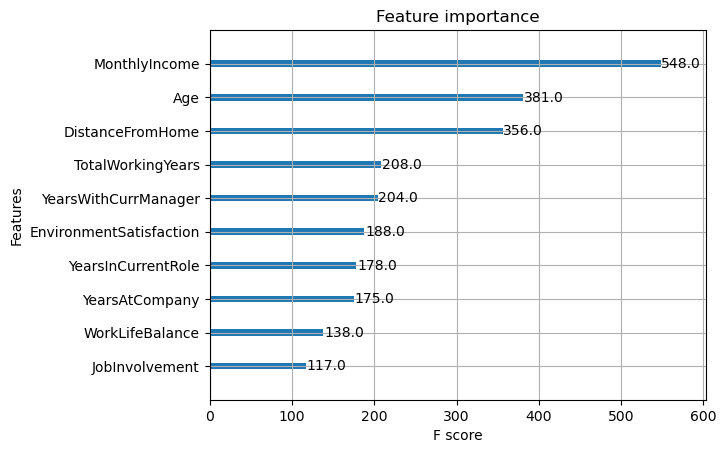

In [135]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df_resampled[['JobLevel','Age','MonthlyIncome','YearsInCurrentRole','TotalWorkingYears','WorkLifeBalance','YearsAtCompany','OverTime','JobRole_Laboratory Technician'
,'YearsWithCurrManager','EnvironmentSatisfaction','StockOptionLevel','JobInvolvement','DistanceFromHome']]
y = df_resampled['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train XGBoost model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.show()

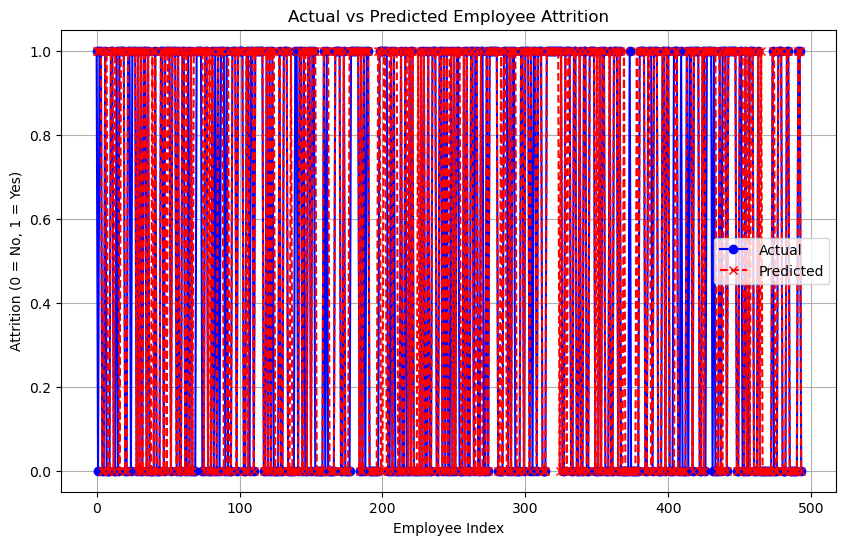

In [136]:
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(range(len(y_pred)), y_pred, label='Predicted', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted Employee Attrition')
plt.xlabel('Employee Index')
plt.ylabel('Attrition (0 = No, 1 = Yes)')
plt.legend()
plt.grid(True)
plt.show()

In [137]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extracting TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)  # aka sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f} (Sensitivity)")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")

# Optional detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy     : 0.8623
Precision    : 0.8352
Recall       : 0.9028 (Sensitivity)
Specificity  : 0.8219
F1 Score     : 0.8677

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.86       247
           1       0.84      0.90      0.87       247

    accuracy                           0.86       494
   macro avg       0.86      0.86      0.86       494
weighted avg       0.86      0.86      0.86       494



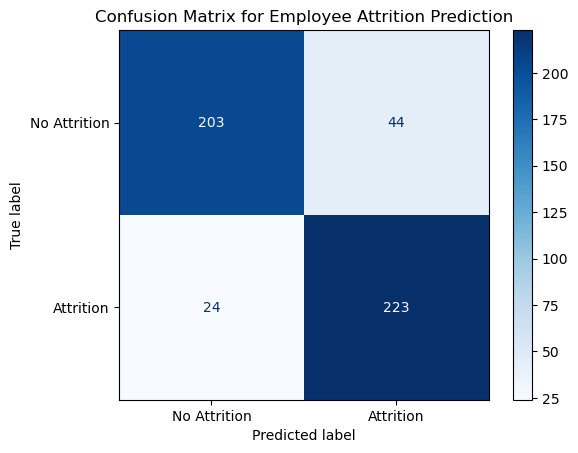

In [138]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['No Attrition', 'Attrition'])
cmd.plot(cmap='Blues')
plt.title('Confusion Matrix for Employee Attrition Prediction')
plt.show()

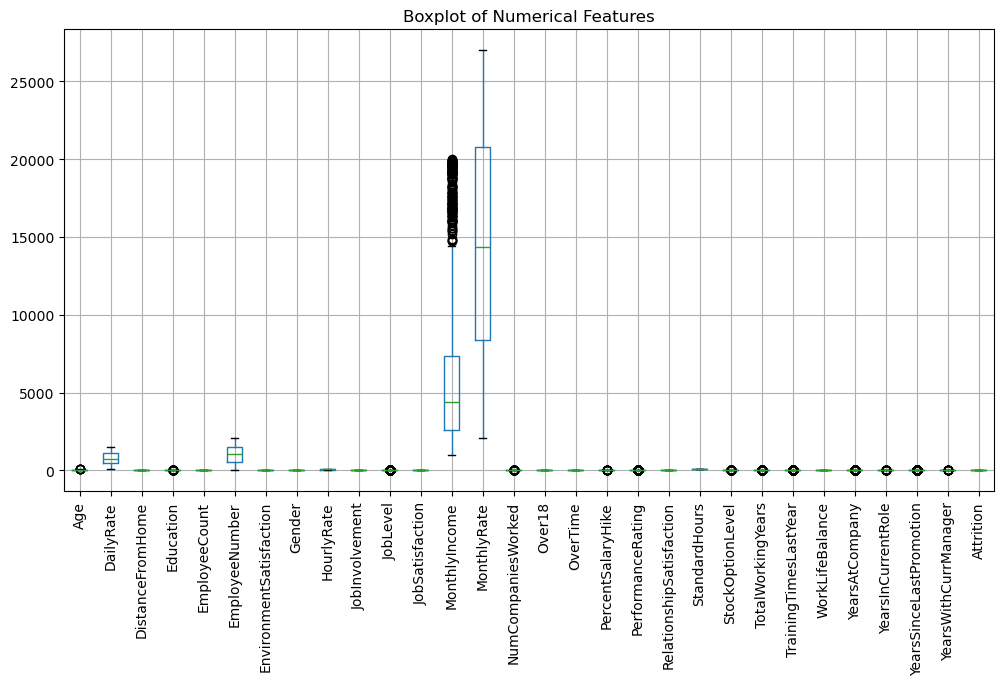

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_columns = df_resampled.select_dtypes(include=['number']).columns

# Plot boxplots for each numerical feature
plt.figure(figsize=(12, 6))
df_resampled[numerical_columns].boxplot(rot=90)  # Rotate labels for readability
plt.title("Boxplot of Numerical Features")
plt.show()


<Axes: >

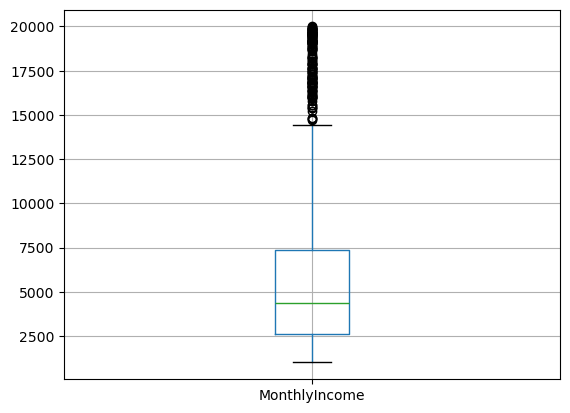

In [140]:
df_resampled[['MonthlyIncome']].boxplot()

In [143]:
df_resampled[['MonthlyIncome']]

,MonthlyIncome
0,5993
1,5130
2,2090
3,2909
4,3468
...,...
2461,2634
2462,5195
2463,4586
2464,2723
